# Journal Comparison & Migration

When you resubmit a paper to a different journal, you need to update your figures to match the new journal's rules.  PlotStyle makes this easy.

**What you'll learn:**
- Compare two journals side by side with `plotstyle.diff()`
- See which journals are most similar to each other
- Automatically adapt a figure for a different journal with `plotstyle.migrate()`
- Browse any journal's full set of rules from the registry

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import plotstyle

## 1. Compare Two Journals

`plotstyle.diff("nature", "science")` compares the rules for both journals and prints a table showing every setting that is different: figure dimensions, font sizes, export formats, and more.

In [2]:
# Human-readable aligned table: Nature → Science
result = plotstyle.diff("nature", "science")
print(result)

Nature → Science
──────────────────────────────────────────────────
Column Width (single):  89.0mm → 57.0mm
Column Width (double):  183.0mm → 121.0mm
Max Height:             247.0mm → 230.0mm
Font Family:            Helvetica, Arial → Helvetica, Myriad Pro, Arial
Max Font Size:          7.0pt → 9.0pt
Panel Label Size:       8.0pt → 9.0pt
Panel Label Case:       lower → upper
Min Line Weight:        0.25pt → 0.28pt


## 2. Access the Diff in Code

Besides printing the table, you can also work with the differences in your code:

- `len(result)`: how many settings differ between the two journals
- `bool(result)`: `True` if there is at least one difference
- `result.differences`: the list of differences, each with a label and both values
- `result.to_dict()`: the full diff as a plain dictionary

In [3]:
print(f"Number of differences: {len(result)}")
print(f"Specs differ: {bool(result)}\n")

# Iterate over each differing field
for d in result.differences:
    print(f"{d.label}:")
    print(f"  {result.journal_a}: {d.value_a}")
    print(f"  {result.journal_b}: {d.value_b}")

Number of differences: 8
Specs differ: True

Column Width (single):
  Nature: 89.0mm
  Science: 57.0mm
Column Width (double):
  Nature: 183.0mm
  Science: 121.0mm
Max Height:
  Nature: 247.0mm
  Science: 230.0mm
Font Family:
  Nature: Helvetica, Arial
  Science: Helvetica, Myriad Pro, Arial
Max Font Size:
  Nature: 7.0pt
  Science: 9.0pt
Panel Label Size:
  Nature: 8.0pt
  Science: 9.0pt
Panel Label Case:
  Nature: lower
  Science: upper
Min Line Weight:
  Nature: 0.25pt
  Science: 0.28pt


## 3. Compare Multiple Journals at Once

If you're deciding where to resubmit, it helps to know which journals require the least changes.  Fewer differences means less work to adapt your figures.

In [4]:
journals = ["nature", "science", "acs", "ieee", "plos"]

print(f"{'Pair':<22} {'Differences':>12}")
print("-" * 36)
for i, a in enumerate(journals):
    for b in journals[i + 1 :]:
        d = plotstyle.diff(a, b)
        print(f"{a} vs {b:<12} {len(d):>12}")

Pair                    Differences
------------------------------------
nature vs science                 8
nature vs acs                     7
nature vs ieee                   12
nature vs plos                   10
science vs acs                    10
science vs ieee                   13
science vs plos                    9
acs vs ieee                   11
acs vs plos                    9
ieee vs plos                   11


## 4. Create a Figure for Nature

Let's make a styled Nature figure.  We'll migrate it to Science in the next section and compare the sizes before and after.

Nature figure size: 3.50 x 2.17 in


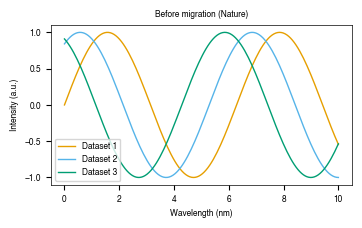

In [ ]:
x = np.linspace(0, 10, 150)

with plotstyle.use("nature"):
    fig, ax = plotstyle.figure("nature", columns=1)
    colors = plotstyle.palette("nature", n=3)
    for i, c in enumerate(colors):
        ax.plot(x, np.sin(x + i), color=c, label=f"Dataset {i + 1}")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity (a.u.)")
    ax.legend()
    ax.set_title("Before migration (Nature)")

w, h = fig.get_size_inches()
print(f"Nature figure size: {w:.2f} x {h:.2f} in")
plt.show()

## 5. Migrate to Science

`plotstyle.migrate()` updates the figure for the target journal in one step:
1. Resizes the figure to the new journal's column width
2. Scales all text proportionally so nothing is too small or too large
3. Applies the new journal's font and style settings

If anything significant changes (like the font family or required resolution), a warning is printed in the output.

> **Note:** `migrate()` modifies the figure in-place. If you need to keep the original, save it first with `plotstyle.savefig()`.

In [ ]:
import warnings

# Show all migration warnings in the cell output
warnings.filterwarnings("always")

plotstyle.migrate(fig, from_journal="nature", to_journal="science")

w, h = fig.get_size_inches()
print(f"Science figure size: {w:.2f} x {h:.2f} in")
ax.set_title("After migration (Science)")
plt.show()
plt.close(fig)

Science figure size: 2.24 x 1.39 in


/var/folders/xt/hqb3p7x962sg0s56_bpzg3sr0000gn/T/ipykernel_60933/870006720.py:6: PlotStyleWarning: Font family changed: ['Helvetica', 'Arial'] → ['Helvetica', 'Myriad Pro', 'Arial']. Update any hardcoded font references in your figure.
  plotstyle.migrate(fig, from_journal="nature", to_journal="science")


## 6. Inspect a Journal's Full Spec

You can look up all the rules for any journal directly from the registry.  This is useful if you want to know the exact column widths, font sizes, DPI requirements, or export formats for a journal.

In [ ]:
spec = plotstyle.registry.get("nature")

print(f"Journal:          {spec.metadata.name}")
print(f"Publisher:        {spec.metadata.publisher}")
print(f"Single col:       {spec.dimensions.single_column_mm} mm")
print(f"Double col:       {spec.dimensions.double_column_mm} mm")
print(f"Font family:      {spec.typography.font_family}")
print(f"Font range:       {spec.typography.min_font_pt}-{spec.typography.max_font_pt} pt")
print(f"Panel labels:     {spec.typography.panel_label_pt} pt {spec.typography.panel_label_weight}")
print(f"Min DPI:          {spec.export.min_dpi}")
print(f"Preferred fmts:   {spec.export.preferred_formats}")
print(f"Colorblind req:   {spec.color.colorblind_required}")
print(f"Grayscale req:    {spec.color.grayscale_required}")

Journal:          Nature
Publisher:        Springer Nature
Single col:       89.0 mm
Double col:       183.0 mm
Font family:      ['Helvetica', 'Arial']
Font range:       5.0–7.0 pt
Panel labels:     8.0 pt bold
Min DPI:          300
Preferred fmts:   ['tiff', 'pdf', 'eps']
Colorblind req:   True
Grayscale req:    False
